# Assignment 3: Convolutional Neural Networks (CNNs)


We first import all we need. These modules help us loading dataset and implementing our deep CNNs.

In [1]:
# this is used to include model diagram in this file. It is not related to the implementation
from IPython.display import Image

# torch and its modules
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Subset

# torchvision and its modules
import torchvision
import torchvision.datasets as DS
import torchvision.transforms as transforms

# for plotting
import matplotlib.pyplot as plt

# for algebric computations
import numpy as np

# wired package to solve the kernel crash issue when plotting on jupyter lab
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

## Question 1: Making Dataset from CIFAR-10
To make our dataset, we first load CIFAR-10.

In [2]:
# We define the transform: this make the dataset into tensors and normalize it properly
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# let's now load CIFAR-10 train and test datasets
train_set = DS.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = DS.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:02<00:00, 62.5MB/s]


### Play around with CIFAR-10
We may now take a look at the datast properties.

In [4]:
# Print size of the sets
print("Size of training set:", len(train_set))
print("Size of testing set:", len(test_set))

# Check a data sample
print(train_set[0])
# print the label
print("Label of the first data sample:", train_set[0][1])

# print classes
print(train_set.class_to_idx)

Size of training set: 50000
Size of testing set: 10000
(tensor([[[-0.5373, -0.6627, -0.6078,  ...,  0.2392,  0.1922,  0.1608],
         [-0.8745, -1.0000, -0.8588,  ..., -0.0353, -0.0667, -0.0431],
         [-0.8039, -0.8745, -0.6157,  ..., -0.0745, -0.0588, -0.1451],
         ...,
         [ 0.6314,  0.5765,  0.5529,  ...,  0.2549, -0.5608, -0.5843],
         [ 0.4118,  0.3569,  0.4588,  ...,  0.4431, -0.2392, -0.3490],
         [ 0.3882,  0.3176,  0.4039,  ...,  0.6941,  0.1843, -0.0353]],

        [[-0.5137, -0.6392, -0.6235,  ...,  0.0353, -0.0196, -0.0275],
         [-0.8431, -1.0000, -0.9373,  ..., -0.3098, -0.3490, -0.3176],
         [-0.8118, -0.9451, -0.7882,  ..., -0.3412, -0.3412, -0.4275],
         ...,
         [ 0.3333,  0.2000,  0.2627,  ...,  0.0431, -0.7569, -0.7333],
         [ 0.0902, -0.0353,  0.1294,  ...,  0.1608, -0.5137, -0.5843],
         [ 0.1294,  0.0118,  0.1137,  ...,  0.4431, -0.0745, -0.2784]],

        [[-0.5059, -0.6471, -0.6627,  ..., -0.1529, -0.2000,

To show an image, you may use the following function.

In [7]:
def imshow(img):
    # remove the impact of normalization
    img = img / 2 + 0.5
    npimg = img.numpy()

    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

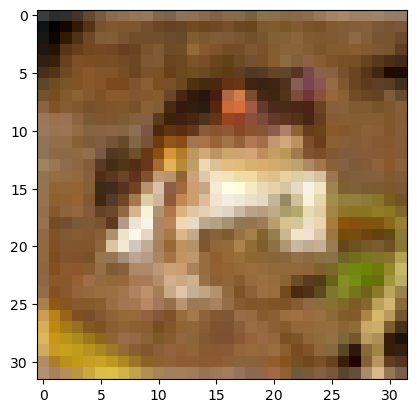

In [9]:
# use imshow() to look into a sample image
sample_img = train_set[0][0]
imshow(sample_img)                 # Display the image

### Make Training and Test Subsets
We first write the function `class_extract` that gets a dataset and a list of classes and returns a subset of dataset that include only the data-points of that class.

In [11]:
def class_extract(cls_list, dataset):
    # initial values
    indx_set = []
    label_set = {}

    # we want later to rewrite the classes
    new_labels = {cls: i for i, cls in enumerate(cls_list)}

    # go through dataset and find points whose labels are in cls_list
    for indx, data in enumerate(dataset):
        if data[1] in cls_list:
            indx_set.append(indx)
            label_set[indx] = new_labels[data[1]]

    # give data-points of the subset new label
    # for instance: we set now cat to class 0 and dog to class 1
    for indx in indx_set:
        dataset.targets[indx] = label_set[indx]

    subset = Subset(dataset, indx_set)
    return subset

We may now try our implementation

In [13]:
cls_list = [train_set.class_to_idx['cat'], train_set.class_to_idx['dog']]
train_subset = class_extract(cls_list, train_set)
test_subset = class_extract(cls_list, test_set)

Now, let's check the size of this reduced dataset.

Size of training set: 10000
Size of testing set: 2000


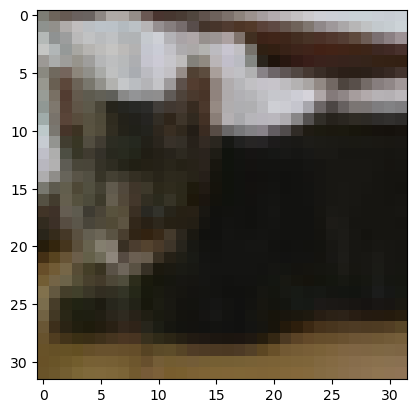

In [14]:
# print the size of test and train subsets

print("Size of training set:", len(train_subset))
print("Size of testing set:", len(test_subset))

sample_img = train_subset[0][0]
imshow(sample_img)                 # Display the image

### Load Training and Test Datasets as Mini-Batches
We now use the subsets to make our training and test datasets.

Use `DataLoader` to load the training and test datasets as sequences of mini-batches with batch size 100. Do not forget to set option `shuffle = True` when you use DataLoader.

In [15]:
batch_size = 100
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=True)

Confirm that the number of mini-batches in iterators `train_loader` and `test_loader` matches what you expect.

In [17]:
# print the size of loaders and compare to what you expect
print("Number of mini-batches in train_loader:", len(train_loader))
print("Number of mini-batches in test_loader:", len(test_loader))

Number of mini-batches in train_loader: 100
Number of mini-batches in test_loader: 20


## Question 2: Implementing Plain CNN
The diagram of the model is given below. You may first try playing with `nn.Conv2d` and `nn.MaxPool2d` to get ready for implementation.

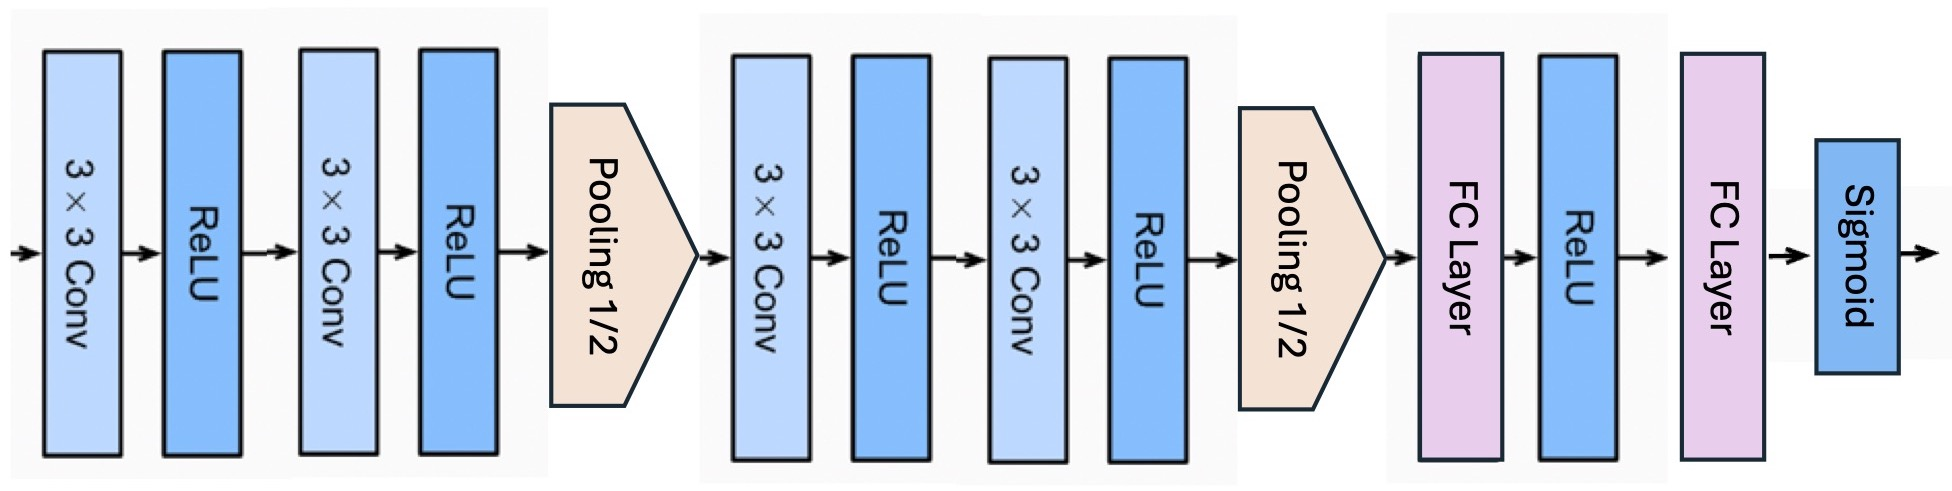

In [ ]:
Image("CNN.jpg")

### Implementing the Plain CNN

In [18]:
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()

        # Conv
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0, stride=1)  # Conv 1
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=0, stride=1)  # Conv  2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # Pooling Layer 3

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0, stride=1)  # Conv  4
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=0, stride=1)  # Conv  5
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # Pooling Layer 6

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 1)

        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        # Convolutional + ReLU + Pooling layers
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool1(x)

        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool2(x)

        # Flatten the output for fully connected layers
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))

        return x

### Implementing the Test Function

When implementing, we could use the variable `device` that specifies the device on which the computation is carried out. You may look at the following sample code.

In [19]:
device = "cpu"
# We may choose a GPU if we have one on our machine
if torch.backends.cuda.is_built():
  # if we have cuda
  # usually on Windows machines with GPU
  device = "cuda"
elif torch.backends.mps.is_built():
  # if we have MPS
  # usually on MAC
  device = "mps"
else:
  # if not we should use our CPU
  device = "cpu"
print(device)
print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce RTX 3070 Laptop GPU


In [77]:
def test(model: myCNN, loss_function, device):

    # we first move our model to the configured device
    model = model.to(device = device)

    # we make sure we are not tracking gradient
    # gradient is used in training, we do not need it for test
    with torch.no_grad():
        risk = 0.0
        accuracy = 0.0
        total_samples = 0
        # here we are only evaluating the model
        model.eval()

        # loop over test mini-batches
        for i, (images, labels) in enumerate(test_loader):
            # reshape labels to have the same form as output
            # make sure labels are of torch.float32 type
            labels = labels.view(-1, 1).type(torch.float32)

            # move tensors to the configured device
            images = images.to(device = device)
            labels = labels.to(device = device)


            # forward pass
            outputs = model(images)
            loss = loss_function(outputs, labels)

            # determine the class of output from sigmoid output
            predicted = (outputs > 0.5).float()

            # compute the fraction of correctly predicted labels
            correct_predict = (predicted == labels).sum()

            risk += loss.item()* images.size(0)
            accuracy += correct_predict.item()
            total_samples += labels.size(0)

        # Compute average test loss and accuracy
        test_risk = risk / total_samples
        test_accuracy = accuracy / total_samples

    return test_risk, test_accuracy

Use the function to test the untrained CNN via the binary cross-entropy function.

In [79]:
# Instantiate the class
test_model = myCNN()

# Define the loss function
loss_function = nn.BCELoss()  # Binary Cross-Entropy Loss

# test it
test_risk, test_accuracy = test(test_model, loss_function, device)

print(test_risk, test_accuracy)

0.6932622492313385 0.5


### Implementing Training Loop

In [81]:
def train(model, num_epochs, device):

    # we first move our model to the configured device
    model = model.to(device = device)

    # set loss to binary CE
    loss_function = nn.BCELoss()

    # Set optimizer with optimizer
    optimizer =torch.optim.Adam(model.parameters(), lr=0.001)

    # Initiate the values
    train_risk = []
    test_risk = []
    test_accuracy = []


    for epoch in range(num_epochs):
        # training risk in one epoch
        risk = 0

        # tell pytorch that you start training
        model.train()

        # loop over training data
        for i, (images, labels) in enumerate(train_loader):

            # reshape labels to have the same form as output
            # make sure labels are of torch.float32 type
            labels = labels.view(-1, 1).type(torch.float32)

            # move tensors to the configured device
            images = images.to(device = device)
            labels = labels.to(device = device)

            # forward pass
            outputs = model(images)
            loss = loss_function(outputs, labels)


            # collect the training loss
            risk += loss.item()

            # backward pass
            optimizer.zero_grad()
            loss.backward()

            # one step of gradient descent
            optimizer.step()

        # first we tell pytorch we are doing evaluation (reassure it, as we have already included it in test())
        model.eval()

        # test out model after update by the optimizer
        risk_epoch, accuracy_epoch = test(model, loss_function, device)

        # collect losses and accuracy
        train_risk.append(risk / len(train_loader.dataset))
        test_risk.append(risk_epoch)
        test_accuracy.append(accuracy_epoch)

        # we can print a message every second epoch
        if (epoch+1) % 2 == 0:
            print(f"Epoch {epoch+1}: "
                f"Train Risk: {train_risk[-1]:.4f}, "
                f"Test Risk: {test_risk[-1]:.4f}, "
                f"Test Accuracy: {test_accuracy[-1]:.4f}"
                )


    # plot the training and test losses
    plt.plot([i+1 for i in range(num_epochs)], train_risk, label='train')
    plt.plot([i+1 for i in range(num_epochs)], test_risk, label='test')
    plt.legend()
    plt.title('Train and Test Risk')
    plt.xlabel('Epoch')
    plt.ylabel('Risk')
    plt.show()

    # plot the test accuracy
    plt.plot([i+1 for i in range(num_epochs)], test_accuracy)
    plt.title('Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.show()

    return train_risk, test_risk, test_accuracy

Now, we can train

Epoch 2: Train Risk: 0.0064, Test Risk: 0.6142, Test Accuracy: 0.6660
Epoch 4: Train Risk: 0.0054, Test Risk: 0.5230, Test Accuracy: 0.7370
Epoch 6: Train Risk: 0.0045, Test Risk: 0.4845, Test Accuracy: 0.7620
Epoch 8: Train Risk: 0.0039, Test Risk: 0.4613, Test Accuracy: 0.7745
Epoch 10: Train Risk: 0.0032, Test Risk: 0.4483, Test Accuracy: 0.7920
Epoch 12: Train Risk: 0.0025, Test Risk: 0.4930, Test Accuracy: 0.7925
Epoch 14: Train Risk: 0.0018, Test Risk: 0.5341, Test Accuracy: 0.7980
Epoch 16: Train Risk: 0.0013, Test Risk: 0.6108, Test Accuracy: 0.8005
Epoch 18: Train Risk: 0.0008, Test Risk: 0.7728, Test Accuracy: 0.7960
Epoch 20: Train Risk: 0.0002, Test Risk: 1.3387, Test Accuracy: 0.7875


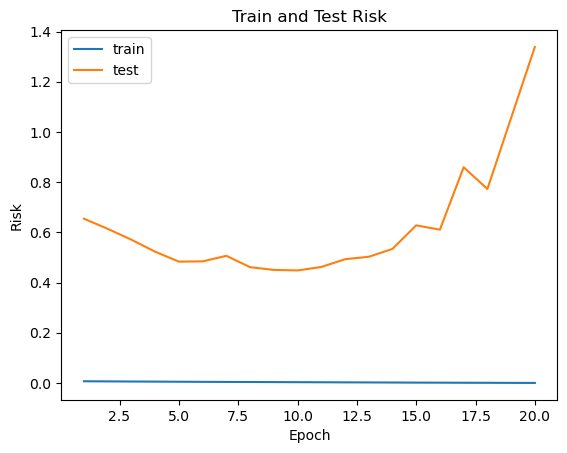

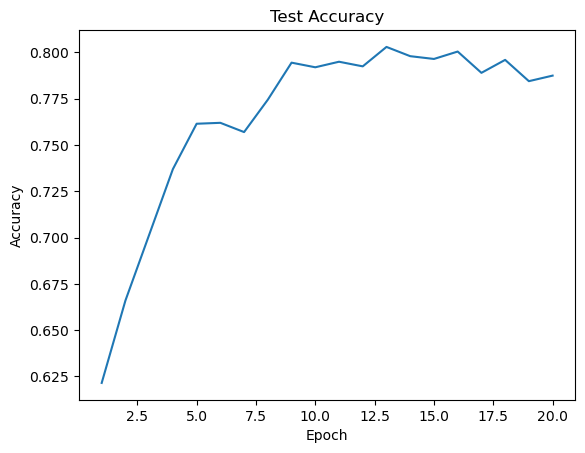

In [84]:
# Instantiate your model
model = myCNN()
num_epochs = 20

train_risk, test_risk, test_accuracy = train(model, num_epochs, device)

### Observation
- The model performs well at the beginning but potentially having the overfitting issues as more epoches has been trained as test risk increased test accuracy decreased a little at certain point. It is struggling with generalization

### Dropout and Batch Normalization
For this task you may copy class `myCNN` into this new class `myCNN_revised` and add the new blocks.

In [85]:
class myCNN_revised(nn.Module):
    def __init__(self):
        super(myCNN_revised, self).__init__()
        # CNN layer with dropout
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0, stride=1)# Conv Layer 1
        self.bn1 = nn.BatchNorm2d(32)
        self.dropout1 = nn.Dropout2d(p=0.4)  # Dropout applied to Conv1
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=0, stride=1)# Conv Layer 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0, stride=1)# Conv Layer 4
        self.bn2 = nn.BatchNorm2d(64)
        self.dropout2 = nn.Dropout2d(p=0.4)  # Dropout applied to Conv4
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=0, stride=1)# Conv Layer 5
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layer
        self.fc1 = nn.Linear(64 * 5 * 5, 128)  # Adjust input size based on feature map
        self.bn_fc1 = nn.BatchNorm1d(128)
        self.dropout_fc = nn.Dropout(0.4)  # Dropout before linear layer
        self.fc2 = nn.Linear(128, 1)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()


    def forward(self, x):
        # First Convolution Block
        x = self.conv1(x)
        x = self.relu(x)
        x = self.bn1(x)
        x = self.dropout1(x)
        x = self.conv2(x)
        x = self.pool1(x)

        # Second Convolution Block
        x = self.conv3(x)
        x = self.relu(x)
        x = self.bn2(x)
        x = self.dropout2(x)
        x = self.conv4(x)
        x = self.pool2(x)
        
        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected Layers
        x = self.dropout_fc(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn_fc1(x)

        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

Repeat the training now

Epoch 2: Train Risk: 0.0063, Test Risk: 0.5976, Test Accuracy: 0.6870
Epoch 4: Train Risk: 0.0058, Test Risk: 0.5410, Test Accuracy: 0.7300
Epoch 6: Train Risk: 0.0055, Test Risk: 0.5122, Test Accuracy: 0.7530
Epoch 8: Train Risk: 0.0052, Test Risk: 0.4888, Test Accuracy: 0.7565
Epoch 10: Train Risk: 0.0050, Test Risk: 0.4725, Test Accuracy: 0.7675
Epoch 12: Train Risk: 0.0047, Test Risk: 0.4759, Test Accuracy: 0.7515
Epoch 14: Train Risk: 0.0046, Test Risk: 0.4417, Test Accuracy: 0.7865
Epoch 16: Train Risk: 0.0043, Test Risk: 0.4298, Test Accuracy: 0.7875
Epoch 18: Train Risk: 0.0040, Test Risk: 0.4400, Test Accuracy: 0.7825
Epoch 20: Train Risk: 0.0038, Test Risk: 0.4239, Test Accuracy: 0.7965


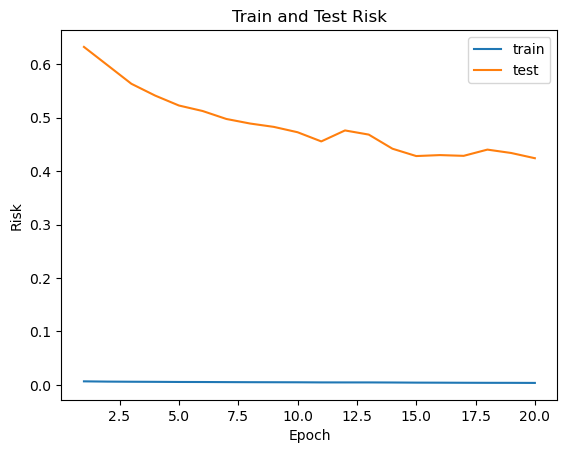

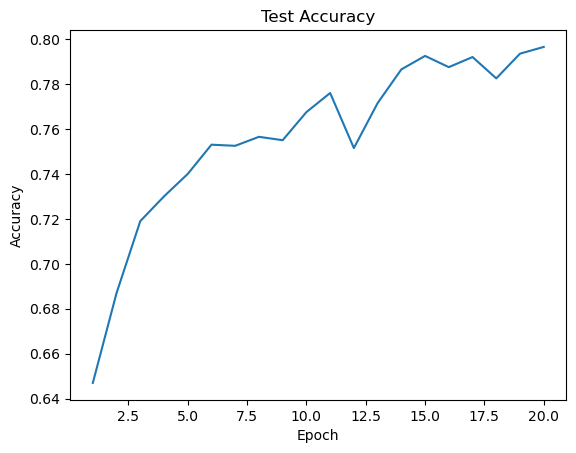

In [86]:
model = myCNN_revised()
num_epochs = 20

train_risk, test_risk, test_accuracy = train(model, num_epochs, device)

### Observation
- The network has a better generalization feature comparing to the network without dropout and batch normalization
- Dropout feature is effective in preventing the overfitting of the model as the test accruacy and risk stablized at certain point
- As it has higher test accruacy and lower risk, batch Normalization helped stablized and accerates the traning and improved the generalization

## Question 3: Implementing CNN with Skip Connection
The diagram of the model is given below.

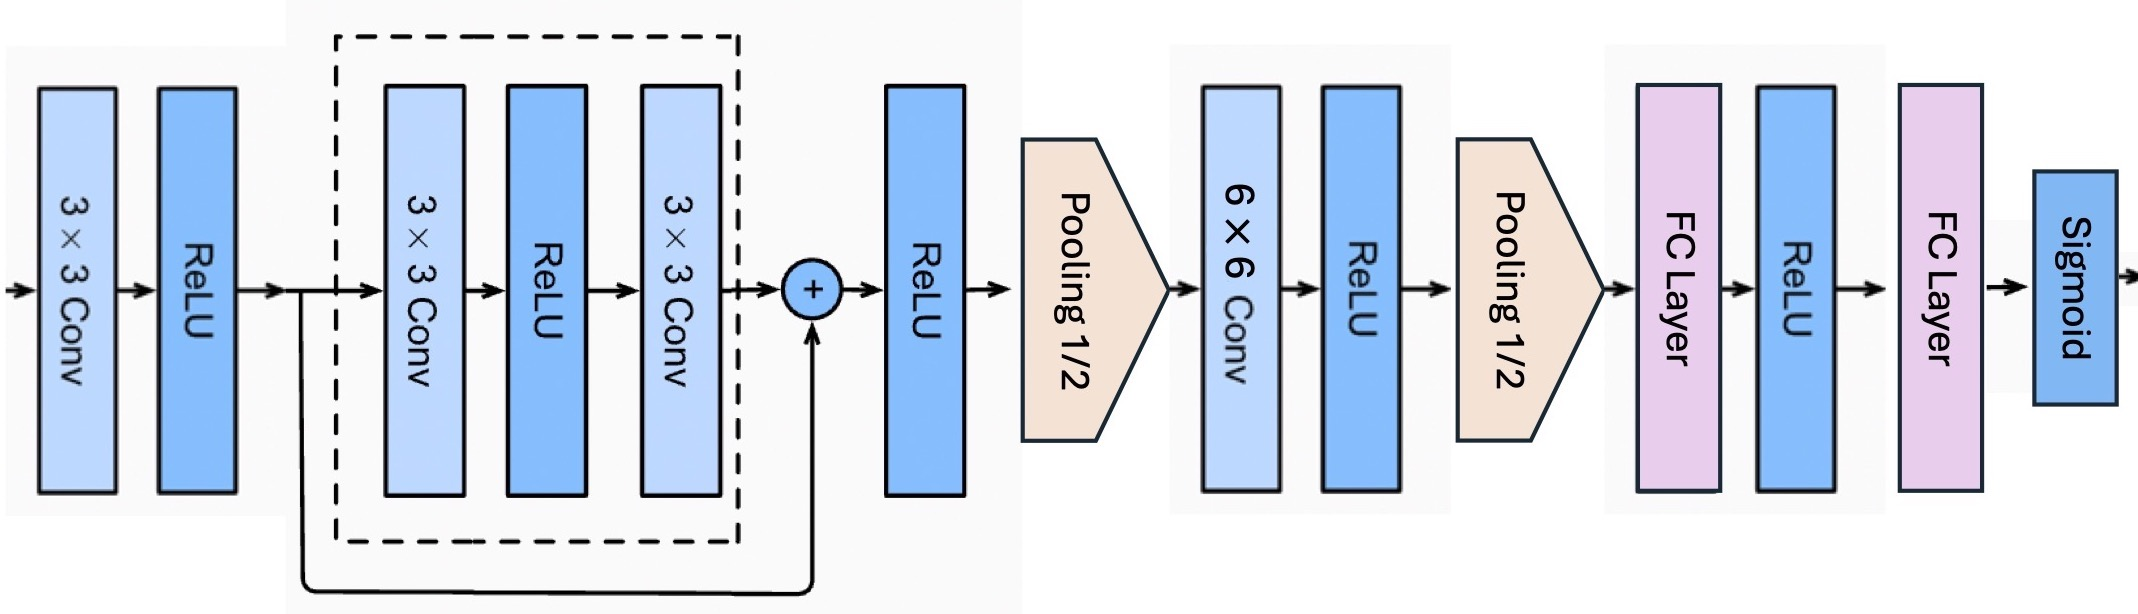

In [38]:
Image('ResNet.jpg')

### Implement the Model
Pay attention to the skip connection. The rest is the same as the plain CNN.

In [87]:
class myResNet(nn.Module):
    def __init__(self):
        super(myResNet, self).__init__()
        # Conv 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0, stride=1)
        # Conv 2 
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1)  
        # Conv 3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1)  
        
        # Pooling Layer 4
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv 5 
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=6, padding=0, stride=1)

        # Pooling Layer 6
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 5 * 5, 128)  
        
        self.fc2 = nn.Linear(128, 1)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
    def forward(self, x):
        #Conv1
        x = self.conv1(x)
        x = self.relu(x)

        #residule save 
        residule = x
        
        #Conv2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.conv3(x)

        #skip connection
        x += residule  
        x = self.relu(x)
       
        # Pooling Layer 4
        x = self.pool1(x)

        # Conv5
        x = self.conv4(x)
        x = self.relu(x)

        # Pooling Layer 6
        x = self.pool2(x)

        # Flatten 
        x = x.view(x.size(0), -1)

        # Fully Connected Layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        
        return x

### Training our ResNet
We already have the training and test functions inplemented.

Epoch 2: Train Risk: 0.0061, Test Risk: 0.6161, Test Accuracy: 0.6625
Epoch 4: Train Risk: 0.0053, Test Risk: 0.5114, Test Accuracy: 0.7400
Epoch 6: Train Risk: 0.0046, Test Risk: 0.4922, Test Accuracy: 0.7565
Epoch 8: Train Risk: 0.0040, Test Risk: 0.4858, Test Accuracy: 0.7735
Epoch 10: Train Risk: 0.0032, Test Risk: 0.5026, Test Accuracy: 0.7730
Epoch 12: Train Risk: 0.0025, Test Risk: 0.5534, Test Accuracy: 0.7750
Epoch 14: Train Risk: 0.0017, Test Risk: 0.6460, Test Accuracy: 0.7665
Epoch 16: Train Risk: 0.0012, Test Risk: 0.7768, Test Accuracy: 0.7585
Epoch 18: Train Risk: 0.0006, Test Risk: 1.1239, Test Accuracy: 0.7655
Epoch 20: Train Risk: 0.0005, Test Risk: 1.2963, Test Accuracy: 0.7620


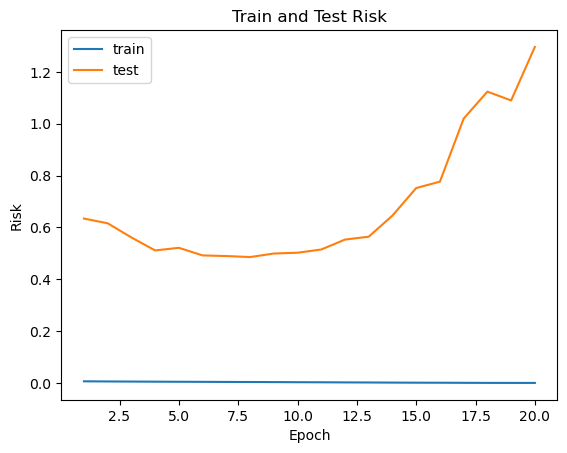

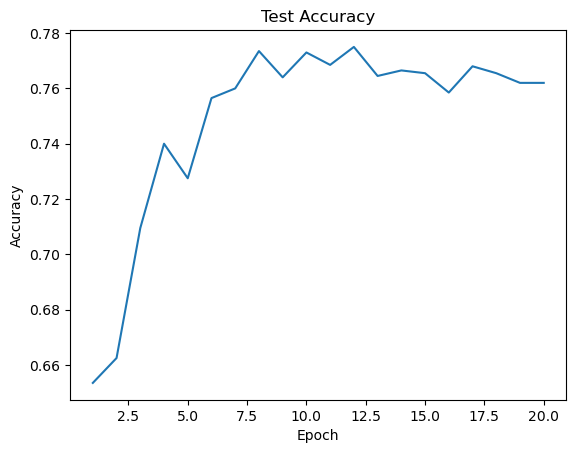

In [88]:
# Make an instant of the class
model = myResNet()
num_epochs = 20

train_risk, train_risk, test_accuracy = train(model, num_epochs, device)

### Observation
- The model overfits quickly after a certain of epochs as the test risks increased while test accuracy stablized
- The skip connection impove the speed of convergence as it reach the peak test accuracy at 8 epochs and while it has a slightly lower testing accuracy compare to original CNN

In [89]:
class myResNet_revised(nn.Module):
    def __init__(self):
        super(myResNet_revised, self).__init__()
        # Conv 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0, stride=1)
        self.bn1 = nn.BatchNorm2d(32) 
        self.dropout1 = nn.Dropout2d(p=0.4)  
        
        # Conv 2 
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1)  
        self.bn2 = nn.BatchNorm2d(32)
        # Conv 3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1)  
        self.bn3 = nn.BatchNorm2d(32)
        
        # Pooling Layer 4
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv 5 
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=6, padding=0, stride=1)
        self.bn4 = nn.BatchNorm2d(64) 
        self.dropout2 = nn.Dropout2d(p=0.4)  
        
        # Pooling Layer 6
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 5 * 5, 128) 
        self.dropout_fc = nn.Dropout(p=0.4)  
        self.bn_fc = nn.BatchNorm1d(128)  
        self.fc2 = nn.Linear(128, 1)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
    def forward(self, x):
        #Conv1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.bn1(x) 
        x = self.dropout1(x)  
        
        #residule save 
        residule = x
        
        #Conv2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.bn2(x)

        #Conv 4
        x = self.conv3(x)
        x = self.bn3(x)
        
        #skip connection
        x += residule  
        x = self.relu(x)
       
        # Pooling Layer 4
        x = self.pool1(x)

        # Conv5
        x = self.conv4(x)
        x = self.relu(x)
        x = self.bn4(x)  
        x = self.dropout2(x)

        # Pooling Layer 6
        x = self.pool2(x)

        # Flatten 
        x = x.view(x.size(0), -1)

        # Fully Connected Layers
        x = self.dropout_fc(x)  
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn_fc(x) 
        
        x = self.fc2(x)
        x = self.sigmoid(x)
        
        return x

Now, repeat the training.

Epoch 2: Train Risk: 0.0063, Test Risk: 0.5962, Test Accuracy: 0.6940
Epoch 4: Train Risk: 0.0059, Test Risk: 0.5397, Test Accuracy: 0.7280
Epoch 6: Train Risk: 0.0055, Test Risk: 0.5232, Test Accuracy: 0.7240
Epoch 8: Train Risk: 0.0051, Test Risk: 0.4917, Test Accuracy: 0.7500
Epoch 10: Train Risk: 0.0049, Test Risk: 0.4800, Test Accuracy: 0.7525
Epoch 12: Train Risk: 0.0046, Test Risk: 0.4453, Test Accuracy: 0.7745
Epoch 14: Train Risk: 0.0043, Test Risk: 0.4528, Test Accuracy: 0.7790
Epoch 16: Train Risk: 0.0042, Test Risk: 0.4226, Test Accuracy: 0.7955
Epoch 18: Train Risk: 0.0040, Test Risk: 0.4214, Test Accuracy: 0.7945
Epoch 20: Train Risk: 0.0038, Test Risk: 0.4078, Test Accuracy: 0.8075


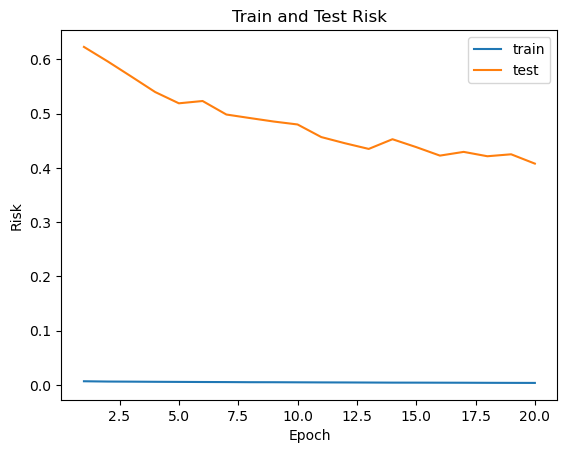

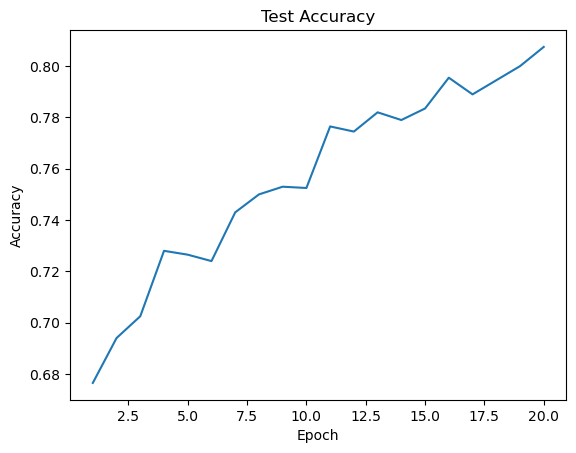

In [90]:
# Make an instant
model = myResNet_revised()
num_epochs = 20

train_risk, train_risk, test_accuracy =  train(model, num_epochs, device)

### Observation
-  the test risk are steadily decreasing and the test accuracy are increasing with more epoches of training ith less fluctuation, it reveals that the model has a good generalization and less overfitting comparing to model without the skip connection and dropout
-  test accuracy is slightly higher than regular ResNet

### ResNet with Only Batch Normalization
You may simply remove the dropouts, and try again training

In [103]:
class myResNet_onlyBN(nn.Module):
    def __init__(self):
        super(myResNet_onlyBN, self).__init__()
        # Conv 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0, stride=1)
        self.bn1 = nn.BatchNorm2d(32)  
        
        # Conv 2 
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1)  
        self.bn2 = nn.BatchNorm2d(32)
        # Conv 3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1)  
        self.bn3 = nn.BatchNorm2d(32)
        
        # Pooling Layer 4
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv 5 
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=6, padding=0, stride=1)
        self.bn4 = nn.BatchNorm2d(64) 
        
        # Pooling Layer 6
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 5 * 5, 128) 
        self.bn_fc = nn.BatchNorm1d(128)  
        self.fc2 = nn.Linear(128, 1)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
    def forward(self, x):
        #Conv1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.bn1(x) 
        
        #residule save 
        residule = x
        
        #Conv2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.bn2(x)

        #Conv 4
        x = self.conv3(x)
        x = self.bn3(x)
        
        #skip connection
        x += residule  
        x = self.relu(x)
       
        # Pooling Layer 4
        x = self.pool1(x)

        # Conv5
        x = self.conv4(x)
        x = self.relu(x)
        x = self.bn4(x)  

        # Pooling Layer 6
        x = self.pool2(x)

        # Flatten 
        x = x.view(x.size(0), -1)

        # Fully Connected Layers 
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn_fc(x) 
        
        x = self.fc2(x)
        x = self.sigmoid(x)
        
        return x

Now repeat training

Epoch 2: Train Risk: 0.0052, Test Risk: 0.5528, Test Accuracy: 0.7205
Epoch 4: Train Risk: 0.0038, Test Risk: 0.5263, Test Accuracy: 0.7485
Epoch 6: Train Risk: 0.0023, Test Risk: 0.5193, Test Accuracy: 0.7705
Epoch 8: Train Risk: 0.0011, Test Risk: 0.6811, Test Accuracy: 0.7670
Epoch 10: Train Risk: 0.0004, Test Risk: 0.7228, Test Accuracy: 0.7835
Epoch 12: Train Risk: 0.0005, Test Risk: 0.8289, Test Accuracy: 0.7645
Epoch 14: Train Risk: 0.0002, Test Risk: 0.9257, Test Accuracy: 0.7825
Epoch 16: Train Risk: 0.0001, Test Risk: 0.9265, Test Accuracy: 0.7890
Epoch 18: Train Risk: 0.0000, Test Risk: 0.9783, Test Accuracy: 0.7990
Epoch 20: Train Risk: 0.0000, Test Risk: 1.0684, Test Accuracy: 0.7925


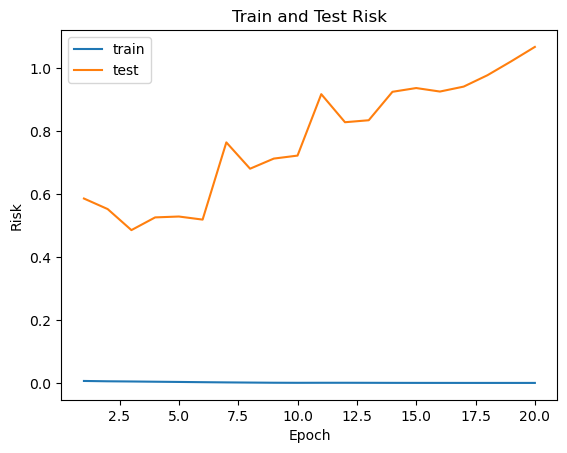

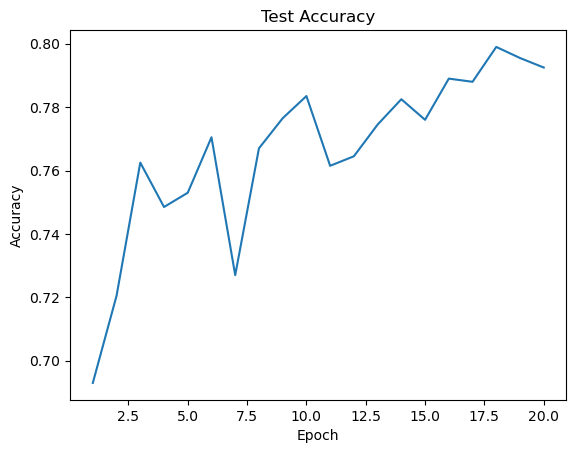

In [106]:
# Make an instant
model = myResNet_onlyBN()
num_epochs = 20

train_risk, train_risk, test_accuracy =  train(model, num_epochs, device)

### Observation
- The test risk is increasing with the increasing of test accuracy which is resulted from the removing of dropuot feature as drop out could provide the regularization
- The removing drop out has creats a large fluctaution on test accuracy and risk as it converges very fast toward the training data (overfitting) while reaveled a high risk when testing on the testing set., it is fragile when encountering new data.